# 📄 Scientific Paper RAG Pipeline  
### CSAI415 – Special Topics in AI | Hands-On Lab

**Full pipeline:**  
`PDF + .bib pair` → Reference Extraction → Citation Graph → Chunking → Embedding → Qdrant + MongoDB → `/search` API

---

## Architecture

```
papers/
  VaswaniSPUJGKP17.pdf   ←─── text extraction
  VaswaniSPUJGKP17.bib   ←─── structured metadata
  devlin2018bert.pdf
  devlin2018bert.bib
         │
         ▼
┌─────────────────────────────────────────────────────────────┐
│  INGESTION LAYER                                            │
│                                                             │
│  BibParser ──────────────────────────────────────────────▶ │
│    title, authors, year, venue, doi, abstract, keywords     │
│                                                             │
│  ReferenceExtractor (priority chain)                        │
│    1. Embedded .bib in PDF  (confidence_base = 1.00)        │
│    2. Embedded .bbl in PDF  (confidence_base = 0.95)        │
│    3. Regex on reference section (confidence varies)        │
│                                                             │
│  CitationResolver                                           │
│    Tier 1: DOI exact        → confidence 1.00               │
│    Tier 2: cite_key exact   → confidence 0.95               │
│    Tier 3: title fuzzy      → confidence 0.85 (single hit)  │
│                               confidence 0.50 (multi-hit)   │
│    Tier 4: author + year    → confidence 0.60               │
│    No match → create stub   → confidence 1.00               │
└─────────────────────────────────────────────────────────────┘
         │
         ▼
┌─────────────────────────────────────────────────────────────┐
│  STORAGE LAYER                                              │
│                                                             │
│  MongoDB                                                    │
│    documents   {doc_id, status, title, authors, …           │
│                 cites:[{doc_id, confidence, match_tier}],   │
│                 citedBy:[doc_id, …]}                        │
│    chunks      {chunk_id, doc_id, page_num, text, …}        │
│                                                             │
│  Qdrant (in-memory)                                         │
│    collection: scientific_papers                            │
│    vector: BGE-small-en-v1.5 (384D, cosine)                 │
└─────────────────────────────────────────────────────────────┘
         │
         ▼
┌─────────────────────────────────────────────────────────────┐
│  RETRIEVAL LAYER                                            │
│                                                             │
│  FastAPI                                                    │
│    GET  /search?q=…&mode=hybrid&min_confidence=0.8          │
│    GET  /documents                                          │
│    GET  /document/{doc_id}/citations                        │
│    GET  /document/{doc_id}/cited_by                         │
│    POST /ingest        (PDF + .bib upload)                  │
│    POST /reconcile     (resolve stubs against new papers)   │
└─────────────────────────────────────────────────────────────┘
```

---

## Sections
1. Environment Setup  
2. BibTeX Parser  
3. Reference Extractor — embedded `.bib` / `.bbl` / regex  
4. Citation Resolver & Confidence Scoring  
5. PDF Text Extraction & Chunking  
6. Embedding with BGE-small  
7. Qdrant Vector Store  
8. MongoDB — Document Registry & Citation Graph  
9. Full Ingestion Pipeline  
10. BM25 Index  
11. FastAPI `/search` + Citation Endpoints  
12. End-to-End Demo  
13. Exercises

## Section 1 — Environment Setup

We install everything up front so the rest of the notebook runs without interruption.

| Package | Purpose |
|---|---|
| `pymupdf` | PDF parsing — text, blocks, embedded files |
| `pymupdf4llm` | Optional ML-assisted layout mode |
| `bibtexparser` | Parse `.bib` files into Python dicts |
| `sentence-transformers` | BGE-small embeddings |
| `qdrant-client` | Vector store (in-memory, no Docker) |
| `pymongo` + `mongomock` | MongoDB interface + in-memory emulator |
| `rank_bm25` | BM25 sparse retrieval |
| `rapidfuzz` | Fast fuzzy string matching for title resolution |
| `fastapi` + `uvicorn` | REST API |
| `nest-asyncio` | Allows asyncio inside Jupyter |

In [1]:
!pip install -q \
    pymupdf pymupdf4llm \
    bibtexparser \
    sentence-transformers \
    qdrant-client \
    pymongo mongomock \
    rank_bm25 \
    rapidfuzz \
    fastapi "uvicorn[standard]" \
    httpx nest-asyncio python-multipart \
    tqdm matplotlib

print("✅ All packages installed")

✅ All packages installed


  DEPRECATION: Building 'bibtexparser' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'bibtexparser'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [1]:
import os, re, json, hashlib, threading, warnings, urllib.request
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Optional, Tuple, Any
from dataclasses import dataclass, field, asdict

import fitz                               # PyMuPDF
import bibtexparser
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from IPython.display import Markdown, display

from rapidfuzz import fuzz

from sentence_transformers import SentenceTransformer

from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance, VectorParams, PointStruct,
    Filter, FieldCondition, MatchValue,
)

import mongomock

from rank_bm25 import BM25Okapi

import nest_asyncio
nest_asyncio.apply()

warnings.filterwarnings("ignore")
print("✅ Imports ready")

✅ Imports ready


## Section 2 — BibTeX Parser

Every paper enters the system as a **pair of files** that share the same filename stem:

```
papers/VaswaniSPUJGKP17.pdf
papers/VaswaniSPUJGKP17.bib
```

The `.bib` file is the **authoritative source of structured metadata** — title, authors, year, venue, DOI, abstract, keywords. We read this *first*, before touching the PDF. If the `.bib` is missing we raise an error immediately rather than silently producing an incomplete record.

### Why not extract metadata from the PDF itself?

PDF metadata (the `DocumentInfo` dictionary) is notoriously unreliable:
- Many PDFs have empty or wrong `Title` / `Author` fields
- Two-column arXiv papers often have the abstract merged with the first body paragraph
- Scanned PDFs have no embedded text metadata at all

The `.bib` file gives us a clean, human-curated record with zero parsing ambiguity.

### The `cite_key` becomes our `doc_id`

BibTeX cite keys (e.g. `VaswaniSPUJGKP17`) are:
- **Human-readable** — immediately meaningful in logs and APIs
- **Unique by convention** — the author assigned it deliberately
- **Stable** — they don't change when the paper is reformatted
- **Already present** in `\cite{}` commands throughout other papers' source

This makes them ideal as the primary key in MongoDB and as vector payload identifiers in Qdrant.

In [35]:
@dataclass
class DocMetadata:
    '''
    Structured representation of a paper's bibliographic metadata.
    Populated from the .bib file; PDF contributes only chunk text.
    '''
    doc_id:      str                      # BibTeX cite key
    status:      str       = "ingested"   # "ingested" | "stub"
    title:       str       = ""
    authors:     List[str] = field(default_factory=list)
    year:        Optional[int] = None
    venue:       str       = ""           # journal / conference
    doi:         str       = ""
    abstract:    str       = ""
    keywords:    List[str] = field(default_factory=list)
    source:      str       = ""           # original filename
    ingested_at: str       = ""
    cites:       List[Dict] = field(default_factory=list)
    cited_by:    List[str]  = field(default_factory=list)

    def to_dict(self) -> Dict:
        return asdict(self)


class BibParser:
    '''
    Parses a .bib file and returns a DocMetadata object.

    The BibTeX cite key becomes the doc_id.
    Multi-author fields are split on ' and ' (standard BibTeX convention).
    Keywords are split on ',' or ';'.
    '''

    def parse(self, bib_path: str) -> DocMetadata:
        path = Path(bib_path)
        assert path.exists(), f"Missing .bib file: {bib_path}"

        with open(path, encoding="utf-8", errors="replace") as f:
            raw = f.read()

        # bibtexparser v1 API
        parser = bibtexparser.bparser.BibTexParser(common_strings=True)
        db     = bibtexparser.loads(raw, parser=parser)

        if not db.entries:
            raise ValueError(f"No BibTeX entries found in {bib_path}")

        # Use the first entry (a paper's .bib should have exactly one)
        entry = db.entries[0]

        authors = self._parse_authors(entry.get("author", ""))
        keywords = self._parse_keywords(entry.get("keywords", ""))

        year_raw = entry.get("year", "")
        try:
            year = int(year_raw)
        except (ValueError, TypeError):
            year = None

        venue = (
            entry.get("journal")
            or entry.get("booktitle")
            or entry.get("publisher")
            or ""
        )

        return DocMetadata(
            doc_id      = entry.get("ID", path.stem),
            title       = self._clean(entry.get("title", path.stem)),
            authors     = authors,
            year        = year,
            venue       = self._clean(venue),
            doi         = entry.get("doi", "").strip(),
            abstract    = self._clean(entry.get("abstract", "")),
            keywords    = keywords,
            source      = path.stem,
            ingested_at = datetime.utcnow().isoformat(),
        )

    def _parse_authors(self, raw: str) -> List[str]:
        '''Split 'Last, First and Last2, First2' into a list.'''
        if not raw.strip():
            return []
        parts = re.split(r"\s+and\s+", raw, flags=re.IGNORECASE)
        return [p.strip() for p in parts if p.strip()]

    def _parse_keywords(self, raw: str) -> List[str]:
        if not raw.strip():
            return []
        return [k.strip() for k in re.split(r"[,;]", raw) if k.strip()]

    def _clean(self, text: str) -> str:
        '''Remove LaTeX braces and normalise whitespace.'''
        text = re.sub(r"\{([^}]*)\}", r"\1", text)   # {word} → word
        text = re.sub(r"\s+", " ", text)
        return text.strip()


# ── Demo ─────────────────────────────────────────────────────────────────────
# We'll download the Attention Is All You Need paper from arXiv for testing.
# Its .bib is provided inline below.

SAMPLE_BIB = '''
@inproceedings{vaswani2017attention,
  author    = {Ashish Vaswani and Noam Shazeer and Niki Parmar and
               Jakob Uszkoreit and Llion Jones and Aidan N. Gomez and
               Lukasz Kaiser and Illia Polosukhin},
  title     = {Attention Is All You Need},
  booktitle = {Advances in Neural Information Processing Systems},
  year      = {2017},
  doi       = {10.48550/arXiv.1706.03762},
  keywords  = {transformer, attention, neural machine translation},
  abstract  = {The dominant sequence transduction models are based on complex
               recurrent or convolutional neural networks. We propose a new
               simple network architecture, the Transformer, based solely on
               attention mechanisms.}
}
'''

# Write demo .bib file
# Path("vaswani2017attention.bib").write_text(SAMPLE_BIB)

bib_parser = BibParser()
meta = bib_parser.parse("./papers/VaswaniSPUJGKP17.bib")

print("📋 Parsed metadata:")
for k, v in meta.to_dict().items():
    if k not in ("cites", "cited_by"):
        print(f"  {k:15s}: {v}")
meta2 = bib_parser.parse("./papers/devlin2018bert.bib")      

print("📋 Parsed metadata:")
for k, v in meta.to_dict().items():
    if k not in ("cites", "cited_by"):
        print(f"  {k:15s}: {v}")

📋 Parsed metadata:
  doc_id         : DBLP:journals/corr/VaswaniSPUJGKP17
  status         : ingested
  title          : Attention Is All You Need
  authors        : ['Ashish Vaswani', 'Noam Shazeer', 'Niki Parmar', 'Jakob Uszkoreit', 'Llion Jones', 'Aidan N. Gomez', 'Lukasz Kaiser', 'Illia Polosukhin']
  year           : 2017
  venue          : CoRR
  doi            : 
  abstract       : 
  keywords       : []
  source         : VaswaniSPUJGKP17
  ingested_at    : 2026-05-11T11:33:43.179679
📋 Parsed metadata:
  doc_id         : DBLP:journals/corr/VaswaniSPUJGKP17
  status         : ingested
  title          : Attention Is All You Need
  authors        : ['Ashish Vaswani', 'Noam Shazeer', 'Niki Parmar', 'Jakob Uszkoreit', 'Llion Jones', 'Aidan N. Gomez', 'Lukasz Kaiser', 'Illia Polosukhin']
  year           : 2017
  venue          : CoRR
  doi            : 
  abstract       : 
  keywords       : []
  source         : VaswaniSPUJGKP17
  ingested_at    : 2026-05-11T11:33:43.179679


## Section 3 — Reference Extractor

Extracting the list of references a paper cites is harder than it looks. The challenge is that the PDF renders references as *visual text* — we need to reverse-engineer the structure from what was originally machine-readable (LaTeX source).

We use a **three-tier priority chain**, trying the most reliable source first:

---

### Priority 1 — Embedded `.bib` file (confidence base: 1.0)

Some authors and publishers attach the original BibTeX file as an embedded stream inside the PDF. This is increasingly common with arXiv submissions. If present, it's the ground truth — structured, cite-keyed, complete.

```python
doc.embfile_count()          # how many embedded files
doc.embfile_info(i)          # name, size, etc.
doc.embfile_get(i)           # raw bytes
```

---

### Priority 2 — Embedded `.bbl` file (confidence base: 0.95)

The `.bbl` file is the *compiled* bibliography that LaTeX generates from the `.bib` + BibTeX style. It looks like:

```latex
\bibitem[Vaswani et al.(2017)]{vaswani2017attention}
  Vaswani, A., et al.
  \newblock Attention is all you need.
  \newblock {\em NeurIPS}, 2017.
```

The cite key `vaswani2017attention` is explicitly present — that's the most valuable piece for matching. We don't need to parse the full author/title fields from the `.bbl` since we can use the cite key to look up the record in MongoDB.

---

### Priority 3 — Regex on the rendered reference section (confidence: varies)

When nothing is embedded, we fall back to parsing the rendered text of the reference section. The strategy:

1. **Locate** the reference section — find the last page containing a heading that matches `References`, `Bibliography`, or `Works Cited`
2. **Segment** individual entries — split on `[N]` numbered markers, or on hanging-indent patterns
3. **Parse** each entry with regex patterns for author/year/title/venue

This is inherently fuzzy. The confidence score assigned downstream reflects the quality of the match against existing MongoDB records.

---

### The `RawReference` dataclass

Regardless of which tier produces the reference, we normalise everything into the same `RawReference` object before passing it to the `CitationResolver`.

In [36]:
@dataclass
class RawReference:
    '''
    A reference entry as extracted from a PDF, before MongoDB resolution.
    The extraction_source tells us which tier produced this entry.
    '''
    raw_text:         str  = ""          # original string from PDF
    cite_key:         Optional[str] = None   # from .bib/.bbl if available
    title:            str  = ""
    authors:          List[str] = field(default_factory=list)
    year:             Optional[int] = None
    doi:              str  = ""
    venue:            str  = ""
    extraction_source: str = "regex"     # "embedded_bib"|"embedded_bbl"|"regex"


class ReferenceExtractor:
    '''
    Extracts the reference list from a PDF using a three-tier priority chain.

    Priority order (most to least reliable):
        1. Embedded .bib file inside the PDF
        2. Embedded .bbl file inside the PDF
        3. Regex parsing of the rendered reference section text

    All three paths return List[RawReference] with a consistent schema.
    The extraction_source field on each entry tells downstream code
    how much to trust the structured fields.
    '''

    # ── Regex patterns for rendered reference text ────────────────────────────

    # Matches [1], [12], [1, 2], [Vas17] style numeric/alphanumeric markers
    RE_NUMBERED = re.compile(r"^\s*\[[\w,\s]+\]\s*", re.MULTILINE)

    # Matches "Author et al. (2017)" or "Author, A. B. (2017)"
    RE_YEAR_PAREN = re.compile(r"\((\d{4}[a-z]?)\)")

    # Matches year written towards the end without parenthesis
    RE_YEAR_NO_PAREN = re.compile(r", (\d{4}).$")
    # DOI patterns
    RE_DOI = re.compile(
        r"(?:doi:|https?://doi\.org/)([^\s,;\]]+)", re.IGNORECASE
    )
    RE_AUTHORS = re.compile(r"^(.+?)\.")

    # Title heuristic: text after year, before venue marker
    # Looks for quoted titles or capitalised phrases
    RE_TITLE_QUOTED = re.compile(r'"([^"]{10,200})"')
    RE_TITLE_PLAIN  = re.compile(
        r"(?:[\.\)]\s)([A-Z][^.]{15,180})\.",
    )

    # Reference section heading
    RE_REF_HEADING = re.compile(
        r"^\s*(References|Bibliography|Works\s+Cited)\s*$",
        re.IGNORECASE | re.MULTILINE,
    )

    def extract(self, pdf_path: str) -> Tuple[List[RawReference], str]:
        '''
        Main entry point. Returns (references, source_tier_used).
        '''
        doc = fitz.open(pdf_path)

        # ── Tier 1: embedded .bib ─────────────────────────────────────────────
        refs = self._try_embedded_bib(doc)
        if refs:
            doc.close()
            return refs, "embedded_bib"

        # ── Tier 2: embedded .bbl ─────────────────────────────────────────────
        refs = self._try_embedded_bbl(doc)
        if refs:
            doc.close()
            return refs, "embedded_bbl"

        # ── Tier 3: regex on rendered text ────────────────────────────────────
        refs = self._parse_rendered_section(doc)
        doc.close()
        return refs, "regex"

    # ── Tier 1 ────────────────────────────────────────────────────────────────

    def _try_embedded_bib(self, doc) -> List[RawReference]:
        '''Look for an embedded .bib file and parse it with bibtexparser.'''
        for i in range(doc.embfile_count()):
            info = doc.embfile_info(i)
            name = info.get("filename", "").lower()
            if name.endswith(".bib"):
                raw_bytes = doc.embfile_get(i)
                try:
                    raw_text = raw_bytes.decode("utf-8", errors="replace")
                    db = bibtexparser.loads(raw_text)
                    refs = []
                    for entry in db.entries:
                        refs.append(RawReference(
                            raw_text  = str(entry),
                            cite_key  = entry.get("ID"),
                            title     = self._clean_latex(entry.get("title", "")),
                            authors   = self._split_authors(entry.get("author", "")),
                            year      = self._parse_year(entry.get("year", "")),
                            doi       = entry.get("doi", "").strip(),
                            venue     = entry.get("journal") or entry.get("booktitle", ""),
                            extraction_source = "embedded_bib",
                        ))
                    if refs:
                        print(f"  📎 Found embedded .bib with {len(refs)} entries")
                        return refs
                except Exception as e:
                    print(f"  ⚠️  Embedded .bib parse error: {e}")
        print("Could not find embedded .bib file")
        return []

    # ── Tier 2 ────────────────────────────────────────────────────────────────

    def _try_embedded_bbl(self, doc) -> List[RawReference]:
        '''Look for an embedded .bbl file and extract cite keys + titles.'''
        for i in range(doc.embfile_count()):
            info = doc.embfile_info(i)
            name = info.get("filename", "").lower()
            if name.endswith(".bbl"):
                raw_bytes = doc.embfile_get(i)
                try:
                    raw_text = raw_bytes.decode("utf-8", errors="replace")
                    return self._parse_bbl(raw_text)
                except Exception as e:
                    print(f"  ⚠️  Embedded .bbl parse error: {e}")
        return []

    def _parse_bbl(self, bbl_text: str) -> List[RawReference]:
        '''
        Parse LaTeX .bbl format.

        Typical structure:
            \\bibitem[label]{cite_key}
              Author, A. (year).
              \\newblock Title of the paper.
              \\newblock {\\em Venue}, pages.
        '''
        refs = []
        # Split on \bibitem
        entries = re.split(r"\\bibitem", bbl_text)[1:]
        for entry in entries:
            cite_key_match = re.match(r"(?:\[[^\]]*\])?\{([^}]+)\}", entry)
            cite_key = cite_key_match.group(1) if cite_key_match else None

            # Title is usually after the first \newblock
            newblocks = re.findall(r"\\newblock\s+([^\n\\]+)", entry)
            title = self._clean_latex(newblocks[0]) if newblocks else ""

            # Year
            year_match = RE_YEAR_PAREN_LOCAL = re.search(r"\((\d{4})\)", entry)
            year = int(year_match.group(1)) if year_match else None

            if cite_key or title:
                refs.append(RawReference(
                    raw_text  = entry[:200],
                    cite_key  = cite_key,
                    title     = title,
                    year      = year,
                    extraction_source = "embedded_bbl",
                ))

        if refs:
            print(f"  📎 Found embedded .bbl with {len(refs)} entries")
        else:
            print("Could not find embedded .bbl file")
        return refs

    # ── Tier 3 ────────────────────────────────────────────────────────────────

    def _parse_rendered_section(self, doc) -> List[RawReference]:
        '''
        Locate the reference section in the rendered PDF text and
        parse individual entries using regex.

        This is the least reliable tier — hence confidence scores
        assigned by CitationResolver will reflect match quality.
        '''
        ref_text = self._extract_reference_section(doc)
        if not ref_text:
            print("  ⚠️  No reference section detected")
            return []
        # print(ref_text)
        entries = self._segment_entries(ref_text)
        print(f"  📝 Regex extracted {len(entries)} reference entries")
        # for entry in entries:
        #     print(entry)
        #     print("*"*50)
        #     print("\n")
        refs = []
        for raw in entries:
            refs.append(self._parse_entry(raw))
        return [r for r in refs if r.title or r.authors]

    def _extract_reference_section(self, doc) -> str:
        '''
        Find the last occurrence of a 'References' heading and
        return all text from that point to end of document.
        '''
        full_text = ""
        ref_start = -1

        for page_num in range(len(doc)):
            page_text = doc[page_num].get_text("text")
            match = list(self.RE_REF_HEADING.finditer(page_text))
            if match:
                # Take the last match on this page
                ref_start = len(full_text) + match[-1].start()
            full_text += page_text + "\n"

        if ref_start == -1:
            return ""
        return full_text[ref_start:]

    def _segment_entries(self, ref_text: str) -> List[str]:
        '''
        Split reference section into individual entries.
        Handles [1] … [N] numbered lists and author-year styles.
        '''
        # Try [N] numbered style first
        parts = self.RE_NUMBERED.split(ref_text)
        parts = [p.strip() for p in parts if len(p.strip()) > 20]
        if len(parts) > 2:
            return parts

        # Fallback: split on blank lines
        parts = re.split(r"\n{2,}", ref_text)
        return [p.strip() for p in parts if len(p.strip()) > 20]

    def _parse_entry(self, raw: str) -> RawReference:
        '''Extract structured fields from a single reference string.'''
        raw_clean = re.sub(r"\s+", " ", raw).strip()
        # print(raw_clean)
        # DOI
        doi_match = self.RE_DOI.search(raw_clean)
        doi = doi_match.group(1) if doi_match else ""

        # Year
        year_match = self.RE_YEAR_PAREN.search(raw_clean)
        if not year_match: #let look for the style where year is at the end of the reference
            year_match = self.RE_YEAR_NO_PAREN.search(raw_clean)

       
        # print(raw)   
        year = int(year_match.group(1)[:-1] if len(year_match.group(1))> 4 else year_match.group(1)) if year_match else 1000
        print("*"*10 , year)
       
            

        # Title — try quoted first, then heuristic capitalised phrase
        title = ""
        tq = self.RE_TITLE_QUOTED.search(raw_clean)
        if tq:
            title = tq.group(1)
        else:
            tp = self.RE_TITLE_PLAIN.search(raw_clean)
            if tp:
                title = tp.group(1)

        # Authors — text before year or title
        authors = []

        author_text = self.RE_AUTHORS.search(raw_clean).group(1)
        # print(author_text)
        authors = self._split_authors(author_text)

        return RawReference(
            raw_text  = raw_clean[:300],
            title     = self._clean_latex(title),
            authors   = authors[:5],     # cap at 5 for storage
            year      = year,
            doi       = doi,
            extraction_source = "regex",
        )

    # ── Helpers ───────────────────────────────────────────────────────────────

    def _clean_latex(self, text: str) -> str:
        text = re.sub(r"\{([^}]*)\}", r"\1", text)
        text = re.sub(r"\\[a-zA-Z]+\s*", " ", text)
        return re.sub(r"\s+", " ", text).strip()

    def _split_authors(self, raw: str) -> List[str]:
        if not raw.strip():
            return []
        parts = re.split(r",\s+and\s+|,\s+(?=[A-Z])", raw, flags=re.IGNORECASE)
        return [p.strip() for p in parts if len(p.strip()) > 1][:10]

    def _parse_year(self, raw: str) -> Optional[int]:
        try:
            return int(str(raw).strip())
        except (ValueError, TypeError):
            return None


# ── Demo ─────────────────────────────────────────────────────────────────────

#PDF_PATH = "vaswani2017attention.pdf"
PDF_PATH = "./papers/VaswaniSPUJGKP17.pdf"
if not Path(PDF_PATH).exists():
    print("Downloading sample PDF...")
    urllib.request.urlretrieve("https://arxiv.org/pdf/1706.03762", PDF_PATH)
    print("✅ Downloaded")

extractor = ReferenceExtractor()
raw_refs, source_tier = extractor.extract(PDF_PATH)

print(f"\n📚 Extraction tier used : {source_tier}")
print(f"   References found     : {len(raw_refs)}")
print(f"\n🔍 First 3 references:")
for r in raw_refs[:3]:
    print(f"\n  cite_key : {r.cite_key}")
    print(f"  title    : {r.title[:80]}")
    print(f"  authors  : {r.authors[:3]}")
    print(f"  year     : {r.year}")
    print(f"  doi      : {r.doi}")
    print(f"  source   : {r.extraction_source}")

Could not find embedded .bib file
  📝 Regex extracted 40 reference entries
********** 2016
********** 2014
********** 2017
********** 1000
********** 2014
********** 2016
********** 2014
********** 2016
********** 2017
********** 2013
********** 2016
********** 2001
********** 1997
********** 1000
********** 2016
********** 2016
********** 2016
********** 2017
********** 2017
********** 2015
********** 2017
********** 2017
********** 2015
********** 1000
********** 1993
********** 1000
********** 2016
********** 2017
********** 1000
********** 2016
********** 2015
********** 2017
********** 2014
********** 2015
********** 2014
********** 2015
********** 2015
********** 2016
********** 2016
********** 1000

📚 Extraction tier used : regex
   References found     : 40

🔍 First 3 references:

  cite_key : None
  title    : Layer normalization
  authors  : ['Jimmy Lei Ba', 'Jamie Ryan Kiros', 'Geoffrey E Hinton']
  year     : 2016
  doi      : 
  source   : regex

  cite_key : None
  title 

## Section 4 — Citation Resolver & Confidence Scoring

The `CitationResolver` takes each `RawReference` and tries to find its corresponding document in MongoDB. This is a **matching problem** — the reference string in paper B may describe paper A in a different format than how A is stored.

### The Four-Tier Matching Strategy

We try tiers in order, stopping at the first successful match:

```
Tier 1 — DOI exact match           confidence = 1.00
          Most reliable. DOIs are globally unique identifiers.
          Fails when the reference doesn't include a DOI (common in older papers).

Tier 2 — cite_key exact match      confidence = 0.95  
          Only available when we got the reference from an embedded .bib/.bbl.
          The same cite key in two papers is almost certainly the same paper.

Tier 3 — Title fuzzy match         confidence = 0.85 (unique hit)
                                   confidence = 0.50 (multiple hits)
          We normalise both titles (lowercase, strip punctuation) then use
          RapidFuzz's token_sort_ratio to handle word-order differences.
          If TWO OR MORE papers in MongoDB exceed the similarity threshold,
          we flag it as ambiguous (confidence 0.50) and pick the best match.

Tier 4 — First-author surname + year  confidence = 0.60
          Last resort. "Vaswani 2017" is usually enough to identify a paper
          within a subdomain, but two papers by the same first author in the
          same year would create a false match.
```

### What happens when no tier matches?

A **stub document** is created in MongoDB for the cited paper:
- `status = "stub"` — signals that no PDF has been ingested yet
- `citedBy` is initialised with the citing paper's `doc_id`
- `doc_id` is derived from the cite key if available, otherwise slugified from `firstauthor_year_firstword`

When the stub paper is later ingested (PDF + .bib pair arrives), the ingestion pipeline calls `upgrade_stub()` which:
1. Finds the stub by `doc_id`
2. Fills in all metadata fields from the `.bib`
3. Sets `status = "ingested"`
4. Preserves the existing `citedBy` list

### The confidence score lives on the citation edge

```json
"cites": [
  {"doc_id": "bahdanau2014neural", "confidence": 1.00, "match_tier": "doi"},
  {"doc_id": "cho2014learning",    "confidence": 0.85, "match_tier": "title_fuzzy"},
  {"doc_id": "stub_xyz",           "confidence": 1.00, "match_tier": "stub_created"}
]
```

The score is on the **edge** (the citation relationship), not the node (the paper). This is the correct modelling: a paper's existence is certain; our confidence that *this reference points to that paper* is what varies.

In [37]:
class CitationResolver:
    '''
    Matches RawReference objects against existing MongoDB documents.

    Matching tiers (highest confidence first):
        1. DOI exact match          → confidence 1.00
        2. cite_key exact match     → confidence 0.95
        3. Title fuzzy match        → confidence 0.85 (unique) / 0.50 (ambiguous)
        4. First-author + year      → confidence 0.60
        No match → create stub      → confidence 1.00

    Each resolved reference becomes a citation edge:
        {"doc_id": str, "confidence": float, "match_tier": str}
    '''

    FUZZY_THRESHOLD = 88        # RapidFuzz score 0-100
    FUZZY_AMBIGUOUS = 2         # ≥ this many hits → ambiguous (conf 0.50)

    def __init__(self, mongo_docs_collection):
        self.docs = mongo_docs_collection

    def resolve_all(
        self,
        raw_refs: List[RawReference],
        citing_doc_id: str,
    ) -> List[Dict]:
        '''
        Resolve a list of RawReferences for a given citing paper.
        Returns citation edge dicts and performs write-backs to MongoDB.
        '''
        edges = []
        for ref in raw_refs:
            edge = self._resolve_one(ref, citing_doc_id)
            if edge:
                edges.append(edge)
        return edges

    def _resolve_one(
        self,
        ref: RawReference,
        citing_doc_id: str,
    ) -> Optional[Dict]:
        '''Resolve a single reference. Returns a citation edge dict.'''

        matched_doc_id, confidence, tier = None, 0.0, ""

        # ── Tier 1: DOI ───────────────────────────────────────────────────────
        if ref.doi:
            doc = self.docs.find_one({"doi": ref.doi})
            if doc:
                matched_doc_id = doc["doc_id"]
                confidence, tier = 1.00, "doi"

        # ── Tier 2: cite_key ──────────────────────────────────────────────────
        if not matched_doc_id and ref.cite_key:
            doc = self.docs.find_one({"doc_id": ref.cite_key})
            if doc:
                matched_doc_id = doc["doc_id"]
                confidence, tier = 0.95, "cite_key"

        # ── Tier 3: fuzzy title ───────────────────────────────────────────────
        if not matched_doc_id and ref.title:
            matched_doc_id, confidence, tier = self._fuzzy_title_match(ref.title)

        # ── Tier 4: first-author + year ───────────────────────────────────────
        if not matched_doc_id and ref.authors and ref.year:
            matched_doc_id, confidence, tier = self._author_year_match(
                ref.authors[0], ref.year
            )

        # ── No match → create stub ────────────────────────────────────────────
        if not matched_doc_id:
            matched_doc_id = self._create_stub(ref, citing_doc_id)
            confidence, tier = 1.00, "stub_created"
        else:
            # Write-back: add citing_doc_id to matched paper's citedBy list
            self._write_back_cited_by(matched_doc_id, citing_doc_id)

        return {
            "doc_id":      matched_doc_id,
            "confidence":  round(confidence, 2),
            "match_tier":  tier,
            "ref_title":   ref.title[:120],   # store for debugging
        }

    # ── Matching helpers ──────────────────────────────────────────────────────

    def _fuzzy_title_match(
        self, query_title: str
    ) -> Tuple[Optional[str], float, str]:
        '''
        Normalise both titles and compare with RapidFuzz token_sort_ratio.
        token_sort_ratio handles word-order differences gracefully
        (e.g. "Neural MT by Jointly Learning..." vs "Jointly Learning to Align...").
        '''
        q_norm = self._norm_title(query_title)
        candidates = []

        for doc in self.docs.find({"title": {"$exists": True}}, {"doc_id": 1, "title": 1}):
            db_norm = self._norm_title(doc.get("title", ""))
            if not db_norm:
                continue
            score = fuzz.token_sort_ratio(q_norm, db_norm)
            if score >= self.FUZZY_THRESHOLD:
                candidates.append((doc["doc_id"], score))

        if not candidates:
            return None, 0.0, ""

        candidates.sort(key=lambda x: x[1], reverse=True)

        if len(candidates) >= self.FUZZY_AMBIGUOUS:
            # Ambiguous — pick best but flag low confidence
            return candidates[0][0], 0.50, "title_fuzzy_ambiguous"

        return candidates[0][0], 0.85, "title_fuzzy"

    def _author_year_match(
        self, first_author: str, year: int
    ) -> Tuple[Optional[str], float, str]:
        '''
        Match on normalised first-author surname + year.
        Extracts surname as last whitespace-separated token before any comma.
        '''
        surname = first_author.split(",")[0].strip().split()[-1].lower()
        docs = list(self.docs.find({"year": year}, {"doc_id": 1, "authors": 1}))

        for doc in docs:
            for author in doc.get("authors", []):
                auth_surname = author.split(",")[0].strip().split()[-1].lower()
                if auth_surname == surname:
                    return doc["doc_id"], 0.60, "author_year"

        return None, 0.0, ""

    def _create_stub(self, ref: RawReference, citing_doc_id: str) -> str:
        '''
        Create a minimal stub document for an unresolved reference.
        The stub is a real MongoDB document with status='stub'.
        '''
        # Derive a doc_id: prefer cite_key, then slugify
        if ref.cite_key:
            stub_id = ref.cite_key
        elif ref.authors and ref.year and ref.title:
            surname  = ref.authors[0].split(",")[0].strip().split()[-1].lower()
            word1    = re.sub(r"[^a-z]", "", ref.title.split()[0].lower()) if ref.title else "unknown"
            stub_id  = f"{surname}{ref.year}{word1}"
        else:
            stub_id = f"stub_{hashlib.md5(ref.raw_text.encode()).hexdigest()[:8]}"

        stub = {
            "doc_id":      stub_id,
            "status":      "stub",
            "title":       ref.title,
            "authors":     ref.authors,
            "year":        ref.year,
            "doi":         ref.doi,
            "venue":       ref.venue,
            "abstract":    "",
            "keywords":    [],
            "source":      "",
            "ingested_at": datetime.utcnow().isoformat(),
            "cites":       [],
            "cited_by":    [citing_doc_id],
        }
        # Upsert: if stub already exists (from another paper's citation), merge citedBy
        existing = self.docs.find_one({"doc_id": stub_id})
        if existing:
            self._write_back_cited_by(stub_id, citing_doc_id)
        else:
            self.docs.insert_one(stub)

        return stub_id

    def _write_back_cited_by(self, target_doc_id: str, citing_doc_id: str):
        '''Add citing_doc_id to target's citedBy list (no duplicates).'''
        self.docs.update_one(
            {"doc_id": target_doc_id},
            {"$addToSet": {"cited_by": citing_doc_id}},
        )

    def _norm_title(self, title: str) -> str:
        '''Lowercase, remove punctuation, collapse whitespace.'''
        t = title.lower()
        t = re.sub(r"[^a-z0-9\s]", " ", t)
        return re.sub(r"\s+", " ", t).strip()

    def upgrade_stub(self, doc_id: str, full_meta: DocMetadata):
        '''
        Upgrade a stub to a full ingested record when the PDF+.bib arrive.
        Preserves existing citedBy list accumulated while the paper was a stub.
        '''
        existing = self.docs.find_one({"doc_id": doc_id})
        if not existing:
            return

        existing_cited_by = existing.get("cited_by", [])
        update = full_meta.to_dict()
        update["status"]   = "ingested"
        update["cited_by"] = list(set(existing_cited_by + update.get("cited_by", [])))

        self.docs.update_one(
            {"doc_id": doc_id},
            {"$set": update},
        )
        print(f"  ⬆️  Upgraded stub '{doc_id}' → ingested (preserved {len(existing_cited_by)} citedBy entries)")


print("✅ CitationResolver defined")

✅ CitationResolver defined


## Section 5 — PDF Text Extraction & Chunking

With metadata handled by the `.bib` file and references handled by `ReferenceExtractor`, the PDF's only job is now to provide **body text for chunking and embedding**. This separation of concerns makes each component simpler and more testable.

### Text Extraction

We use PyMuPDF's `get_text("text")` as the default. For most arXiv papers this produces clean, column-ordered text. If you encounter garbled two-column output (words from both columns interleaved), switch to `layout_mode="blocks"` which sorts text blocks left-column-first.

> 💡 **Pro tip:** Run the Layout Sensitivity check in Exercise 1 before processing a new paper corpus — it takes 5 seconds and will tell you if column detection is needed.

### Chunking Strategy

We use a **sliding window** over words (not tokens) because:
- Word counts are language-model agnostic
- 400 words ≈ 512 tokens for English text (close enough for BGE-small's 512-token limit)
- The 50-word overlap preserves context across chunk boundaries — a sentence that starts at the end of chunk N is fully present in chunk N+1

Each chunk inherits rich metadata from the page:
- `doc_id`, `source` — which paper
- `page_num`, `chunk_seq` — position within the paper
- `section` — closest detected heading (useful for filtered search)

### Abstract as a Special Chunk

The abstract from the `.bib` file is stored as a chunk with `chunk_type="abstract"`. This is valuable because:
- Abstracts compress the paper's core contribution into ~150 words — semantically very dense
- Queries like *"papers about positional encoding"* will match abstract chunks first
- We tag it so you can optionally up-weight or filter abstract chunks in search

📄 Pages extracted : 15
🧩 Total chunks    : 26
   Abstract chunks : 0
   Body chunks     : 26

📋 Abstract chunk preview:
   Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works. Attention Is All You Need ...


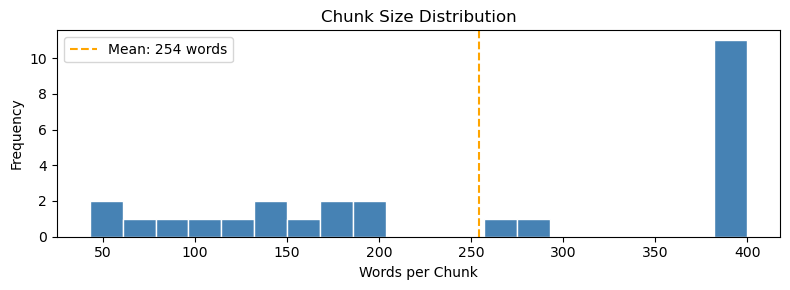

In [38]:
class PDFTextExtractor:
    '''
    Extracts body text from a PDF for chunking.
    Metadata comes from the .bib — this class is text-only.

    layout_mode:
        'text'   — fast naive reading order (default, works for most arXiv PDFs)
        'blocks' — column-aware: sorts text blocks left-col first (use for
                   two-column IEEE/ACM papers if 'text' produces garbled output)
    '''

    def __init__(self, layout_mode: str = "text", min_chars: int = 50):
        assert layout_mode in ("text", "blocks")
        self.layout_mode = layout_mode
        self.min_chars   = min_chars

    def extract_pages(self, pdf_path: str, doc_id: str) -> List[Dict]:
        '''
        Returns a list of page dicts:
            {doc_id, source, page_num, text, headings, layout_mode}
        '''
        doc    = fitz.open(pdf_path)
        source = Path(pdf_path).name
        pages  = []

        for page_num, page in enumerate(doc, start=1):
            if self.layout_mode == "blocks":
                text = self._extract_blocks(page)
            else:
                text = page.get_text("text")

            text = self._clean(text)
            if len(text) < self.min_chars:
                continue

            pages.append({
                "doc_id":      doc_id,
                "source":      source,
                "page_num":    page_num,
                "text":        text,
                "headings":    self._extract_headings(page),
                "layout_mode": self.layout_mode,
            })

        doc.close()
        return pages

    def _extract_blocks(self, page) -> str:
        '''
        Column-aware extraction: split page at midpoint, sort each column
        top-to-bottom, then concatenate left column before right column.
        '''
        blocks    = page.get_text("blocks")          # (x0,y0,x1,y1,text,…)
        mid       = page.rect.width / 2
        left_col  = sorted([b for b in blocks if b[0] < mid],  key=lambda b: b[1])
        right_col = sorted([b for b in blocks if b[0] >= mid], key=lambda b: b[1])
        return " ".join(b[4] for b in left_col + right_col if b[4].strip())

    def _extract_headings(self, page) -> List[str]:
        '''Detect bold or large-font spans as section headings.'''
        headings = []
        for block in page.get_text("dict")["blocks"]:
            if block.get("type") != 0:
                continue
            for line in block.get("lines", []):
                for span in line.get("spans", []):
                    flags = span.get("flags", 0)
                    size  = span.get("size", 0)
                    text  = span.get("text", "").strip()
                    if text and (bool(flags & 16) or size > 13) and len(text) < 120:
                        headings.append(text)
        return list(dict.fromkeys(headings))

    def _clean(self, text: str) -> str:
        text = re.sub(r"-\n", "", text)          # dehyphenate
        text = re.sub(r"\n+", " ", text)
        text = re.sub(r"[ \t]{2,}", " ", text)
        return text.strip()


class SlidingWindowChunker:
    '''
    Splits page text into overlapping chunks.

    chunk_size : target size in words (≈ tokens for English)
    overlap    : word overlap between consecutive chunks
    '''

    def __init__(self, chunk_size: int = 400, overlap: int = 50):
        self.chunk_size = chunk_size
        self.overlap    = overlap

    def chunk_pages(self, pages: List[Dict], abstract: str = "") -> List[Dict]:
        '''
        Produces chunks from all pages plus an optional abstract chunk.
        The abstract chunk (from .bib) gets chunk_type='abstract'.
        '''
        chunks = []

        # ── Abstract as a special chunk ───────────────────────────────────────
        if abstract and abstract.strip():
            chunks.append({
                "chunk_id":   f"{pages[0]['doc_id']}_abstract",
                "doc_id":     pages[0]["doc_id"],
                "source":     pages[0]["source"],
                "page_num":   0,
                "chunk_seq":  0,
                "section":    "Abstract",
                "chunk_type": "abstract",
                "text":       abstract.strip(),
                "word_count": len(abstract.split()),
            })

        # ── Body text chunks ──────────────────────────────────────────────────
        for page in pages:
            for chunk in self._chunk_text(page):
                chunks.append(chunk)

        return chunks

    def _chunk_text(self, page: Dict) -> List[Dict]:
        words  = page["text"].split()
        if not words:
            return []

        step    = self.chunk_size - self.overlap
        chunks  = []
        idx     = 0
        seq     = 0

        while idx < len(words):
            window = words[idx : idx + self.chunk_size]
            section = page["headings"][0] if page["headings"] else "Body"

            chunks.append({
                "chunk_id":   f"{page['doc_id']}_p{page['page_num']}_c{seq}",
                "doc_id":     page["doc_id"],
                "source":     page["source"],
                "page_num":   page["page_num"],
                "chunk_seq":  seq,
                "section":    section,
                "chunk_type": "body",
                "text":       " ".join(window),
                "word_count": len(window),
            })

            idx += step
            seq += 1

        return chunks


# ── Demo ─────────────────────────────────────────────────────────────────────
text_extractor = PDFTextExtractor(layout_mode="text")
pages          = text_extractor.extract_pages(PDF_PATH, doc_id=meta.doc_id)

chunker = SlidingWindowChunker(chunk_size=400, overlap=50)
chunks  = chunker.chunk_pages(pages, abstract=meta.abstract)

abstract_chunks = [c for c in chunks if c["chunk_type"] == "abstract"]
body_chunks     = [c for c in chunks if c["chunk_type"] == "body"]

print(f"📄 Pages extracted : {len(pages)}")
print(f"🧩 Total chunks    : {len(chunks)}")
print(f"   Abstract chunks : {len(abstract_chunks)}")
print(f"   Body chunks     : {len(body_chunks)}")
print(f"\n📋 Abstract chunk preview:")
print(f"   {chunks[0]['text'][:200]}...")

# Chunk size distribution
word_counts = [c["word_count"] for c in chunks]
plt.figure(figsize=(8, 3))
plt.hist(word_counts, bins=20, color="steelblue", edgecolor="white")
plt.axvline(np.mean(word_counts), color="orange", linestyle="--",
            label=f"Mean: {np.mean(word_counts):.0f} words")
plt.xlabel("Words per Chunk"); plt.ylabel("Frequency")
plt.title("Chunk Size Distribution"); plt.legend(); plt.tight_layout(); plt.show()

## Section 6 — Embedding with BGE-small

We convert each chunk's text into a dense vector using `BAAI/bge-small-en-v1.5`.

### Why BGE-small over MiniLM?

Both are small, fast models suitable for a lab environment. BGE-small wins on MTEB retrieval benchmarks because it was trained with a **query instruction prefix** that explicitly separates the roles of query and document:

- **Documents** are encoded as-is
- **Queries** are prefixed with `"Represent this sentence for searching relevant passages: "`

This asymmetry dramatically improves retrieval precision compared to symmetric encoders like MiniLM.

### Normalisation

We set `normalize_embeddings=True` so all vectors lie on the unit hypersphere. This means **cosine similarity = dot product** — making Qdrant search faster and avoiding the need to configure distance metrics carefully.

### Abstract chunk weighting

The abstract chunk encodes the paper's core contribution in ~150 words. During retrieval, abstract chunks naturally score high for topic-level queries. If you want to *boost* them explicitly, you can store a `boost_factor` in the Qdrant payload and apply it in post-processing — that's Exercise 3.

In [39]:
class EmbeddingEngine:
    '''
    Wraps BGE-small with batch encoding and the BGE query instruction prefix.

    Documents are encoded without prefix.
    Queries are encoded with the instruction prefix for better retrieval.
    All embeddings are L2-normalised → cosine similarity = dot product.
    '''

    QUERY_PREFIX = "Represent this sentence for searching relevant passages: "

    def __init__(self, model_name: str = "BAAI/bge-small-en-v1.5"):
        print(f"⏳ Loading: {model_name}")
        self.model      = SentenceTransformer(model_name)
        self.model_name = model_name
        self.dim        = self.model.get_embedding_dimension()
        print(f"✅ Loaded | dim={self.dim}")

    def embed_documents(self, texts: List[str], batch_size: int = 32) -> np.ndarray:
        '''Encode document chunks — no prefix.'''
        return self.model.encode(
            texts,
            batch_size=batch_size,
            show_progress_bar=True,
            normalize_embeddings=True,
        )

    def embed_query(self, query: str) -> np.ndarray:
        '''Encode a search query — with BGE instruction prefix.'''
        return self.model.encode(
            self.QUERY_PREFIX + query,
            normalize_embeddings=True,
        )


# ── Load model and embed all chunks ─────────────────────────────────────────
embedder   = EmbeddingEngine()
texts      = [c["text"] for c in chunks]
embeddings = embedder.embed_documents(texts)

# Attach embeddings to chunks
for chunk, emb in zip(chunks, embeddings):
    chunk["embedding"] = emb.tolist()

print(f"\n📐 Embedding matrix : {embeddings.shape}")
print(f"   Vectors          : {len(chunks)} × {embedder.dim}D float32")

# ── Sanity check ─────────────────────────────────────────────────────────────
test_query = "multi-head attention mechanism"
qvec       = embedder.embed_query(test_query)
scores     = embeddings @ qvec
top5       = np.argsort(scores)[::-1][:5]

print(f"\n🔎 Top-5 for '{test_query}':")
for rank, i in enumerate(top5, 1):
    ctype = chunks[i]["chunk_type"]
    print(f"  [{rank}] score={scores[i]:.4f} | {ctype} | pg {chunks[i]['page_num']} | {chunks[i]['text'][:80]}...")

⏳ Loading: BAAI/bge-small-en-v1.5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Loaded | dim=384


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


📐 Embedding matrix : (26, 384)
   Vectors          : 26 × 384D float32

🔎 Top-5 for 'multi-head attention mechanism':
  [1] score=0.7987 | body | pg 5 | output values. These are concatenated and once again projected, resulting in the...
  [2] score=0.7686 | body | pg 4 | Scaled Dot-Product Attention Multi-Head Attention Figure 2: (left) Scaled Dot-Pr...
  [3] score=0.7229 | body | pg 2 | ConvS2S and logarithmically for ByteNet. This makes it more difficult to learn d...
  [4] score=0.7065 | body | pg 13 | Attention Visualizations It is in this spirit that a majority of American govern...
  [5] score=0.7042 | body | pg 6 | ..., zn), with xi, zi ∈Rd, such as a hidden layer in a typical sequence transduc...


## Section 7 — Qdrant Vector Store

Qdrant stores the embedding vectors and exposes approximate nearest-neighbour search. We run it in **in-memory mode** — no Docker, no installation beyond `pip`.

### What Qdrant stores

Each **point** in Qdrant has three parts:
- `id` — an integer (the chunk's position in the list)
- `vector` — the 384D float32 embedding
- `payload` — a JSON dict of all chunk metadata (doc_id, page_num, section, chunk_type, text, …)

We store the full text and metadata in the payload so search results are self-contained — no second MongoDB lookup needed for basic display.

### Payload-based filtering

Qdrant supports filtering search results by payload fields **before** the ANN search runs (not as a post-filter). This is critical for:
- `doc_id` filter — search within a specific paper only
- `chunk_type` filter — search only abstract chunks, or only body chunks
- Combined filters for advanced queries

### Production note

To connect to a real Qdrant server (e.g. via Docker Compose in production):
```python
client = QdrantClient(host="qdrant", port=6333)
```
Everything else stays the same.

In [40]:
class VectorStore:
    '''
    Qdrant-backed vector store.
    Runs in-memory by default; swap to QdrantClient(host=...) for production.
    '''

    COLLECTION = "scientific_papers"

    def __init__(self, dim: int):
        self.client = QdrantClient(":memory:")
        self.dim    = dim
        self._create_collection()

    def _create_collection(self):
        self.client.recreate_collection(
            collection_name=self.COLLECTION,
            vectors_config=VectorParams(size=self.dim, distance=Distance.COSINE),
        )
        print(f"✅ Qdrant collection '{self.COLLECTION}' ready (dim={self.dim})")

    def upsert(self, chunks: List[Dict]) -> int:
        '''Insert/update chunks. Payload stores all fields except 'embedding'.'''
        points = []
        for i, chunk in enumerate(chunks):
            payload = {k: v for k, v in chunk.items() if k != "embedding"}
            points.append(PointStruct(id=i, vector=chunk["embedding"], payload=payload))

        for start in range(0, len(points), 100):
            self.client.upsert(
                collection_name=self.COLLECTION,
                points=points[start:start + 100],
            )
        return len(points)

    def search(
        self,
        query_vector: List[float],
        top_k: int = 5,
        doc_id: Optional[str] = None,
        chunk_type: Optional[str] = None,
    ) -> List[Dict]:
        '''
        Dense vector search with optional payload filters.

        doc_id     — restrict to a single document
        chunk_type — 'abstract' | 'body' | None (both)
        '''
        must_conditions = []
        if doc_id:
            must_conditions.append(
                FieldCondition(key="doc_id", match=MatchValue(value=doc_id))
            )
        if chunk_type:
            must_conditions.append(
                FieldCondition(key="chunk_type", match=MatchValue(value=chunk_type))
            )

        query_filter = Filter(must=must_conditions) if must_conditions else None

        results = self.client.query_points(
            collection_name=self.COLLECTION,
            query=query_vector,
            limit=top_k,
            query_filter=query_filter,
            with_payload=True,
        )

        # print(results)
        return [
            {"chunk_id": r.payload["chunk_id"], "score": round(r.score, 4),
             "payload": r.payload}
            for r in results.points
        ]


# ── Upsert ───────────────────────────────────────────────────────────────────
vector_store = VectorStore(dim=embedder.dim)
n = vector_store.upsert(chunks)
print(f"📦 Upserted {n} vectors")
# print(dir(vector_store.client))

# ── Test: filter to abstract chunks only ─────────────────────────────────────
qvec = embedder.embed_query("transformer sequence to sequence").tolist()
abstract_results = vector_store.search(qvec, top_k=3, chunk_type="abstract")
print(f"\n🔎 Abstract-only search:")
for r in abstract_results:
    print(f"  score={r['score']} | {r['payload']['text'][:100]}...")

✅ Qdrant collection 'scientific_papers' ready (dim=384)
📦 Upserted 26 vectors

🔎 Abstract-only search:


## Section 8 — MongoDB — Document Registry & Citation Graph

MongoDB plays two roles in this pipeline:

### Role 1: Document Registry
One document per ingested paper (or stub). Stores all bibliographic metadata plus the citation graph fields:
- `cites[]` — outgoing citation edges with confidence scores
- `cited_by[]` — incoming citation references (list of `doc_id`s)

### Role 2: Chunk Index
One document per text chunk, mirroring the Qdrant payload. This allows MongoDB queries against chunk metadata (e.g. "all chunks from papers published after 2020") that Qdrant's payload filtering doesn't support as flexibly.

### Collections

```
rag_db.documents   — one doc per paper (ingested or stub)
rag_db.chunks      — one doc per chunk (no embedding vectors)
```

### Indexes
We create indexes on the fields most commonly used for filtering and matching:
- `doc_id` (unique) — primary lookup key
- `doi` — for Tier 1 citation matching
- `title` — for Tier 3 fuzzy matching
- `status` — filter ingested vs stub documents
- `chunks.doc_id` — look up all chunks for a paper

### The citation graph in MongoDB

The `cites` and `cited_by` fields form a **bidirectional citation graph**:

```
        ┌───────────────────────────────────────┐
        │  vaswani2017attention                 │
        │  cites: [                             │
        │    {doc_id: "bahdanau2014neural",     │
        │     confidence: 1.0,                  │
        │     match_tier: "doi"}                │
        │  ]                                    │
        └──────────────────┬────────────────────┘
                           │  write-back
                           ▼
        ┌───────────────────────────────────────┐
        │  bahdanau2014neural                   │
        │  cited_by: ["vaswani2017attention",   │
        │             "devlin2018bert", ...]    │
        └───────────────────────────────────────┘
```

This structure lets you answer graph queries like:
- "Which papers does X cite?" → `documents.find({doc_id: X}, {cites: 1})`
- "Which papers cite X?" → `documents.find({doc_id: X}, {cited_by: 1})`
- "Papers that are highly cited within our corpus" → sort by `len(cited_by)`

In [41]:
class MetadataStore:
    '''
    MongoDB-backed store for document metadata, citation graph, and chunk index.

    Uses mongomock for local/lab use — swap uri= for a real MongoDB connection.

    Collections:
        documents — one record per paper (ingested or stub)
        chunks    — one record per text chunk (no embedding vectors)
    '''

    def __init__(self, uri: Optional[str] = None, db_name: str = "rag_db"):
        if uri:
            from pymongo import MongoClient
            self.client = MongoClient(uri)
        else:
            self.client = mongomock.MongoClient()

        self.db     = self.client[db_name]
        self.docs   = self.db["documents"]
        self.chunks = self.db["chunks"]

        # Indexes for fast lookups
        self.docs.create_index("doc_id",  unique=True)
        self.docs.create_index("doi")
        self.docs.create_index("title")
        self.docs.create_index("status")
        self.chunks.create_index("chunk_id", unique=True)
        self.chunks.create_index("doc_id")

        print(f"✅ MongoDB (mongomock) ready | DB: {db_name}")

    # ── Document operations ───────────────────────────────────────────────────

    def upsert_document(self, doc: DocMetadata) -> str:
        '''Insert or update a document. Preserves existing cited_by on update.'''
        existing = self.docs.find_one({"doc_id": doc.doc_id})
        d = doc.to_dict()

        if existing and existing.get("status") == "stub":
            # Upgrading a stub: preserve accumulated citedBy
            d["cited_by"] = list(set(
                existing.get("cited_by", []) + d.get("cited_by", [])
            ))

        self.docs.update_one(
            {"doc_id": doc.doc_id},
            {"$set": d},
            upsert=True,
        )
        return doc.doc_id

    def update_cites(self, doc_id: str, citation_edges: List[Dict]):
        '''Set the cites[] field for a document after citation resolution.'''
        self.docs.update_one(
            {"doc_id": doc_id},
            {"$set": {"cites": citation_edges}},
        )

    def get_document(self, doc_id: str) -> Optional[Dict]:
        doc = self.docs.find_one({"doc_id": doc_id})
        if doc:
            doc.pop("_id", None)
        return doc

    def list_documents(self, status: Optional[str] = None) -> List[Dict]:
        query = {"status": status} if status else {}
        return [
            {k: v for k, v in d.items() if k != "_id"}
            for d in self.docs.find(query)
        ]

    def get_citations(
        self, doc_id: str, min_confidence: float = 0.0
    ) -> List[Dict]:
        '''Return outgoing citation edges, optionally filtered by confidence.'''
        doc = self.get_document(doc_id)
        if not doc:
            return []
        return [
            e for e in doc.get("cites", [])
            if e.get("confidence", 0) >= min_confidence
        ]

    def get_cited_by(self, doc_id: str) -> List[str]:
        '''Return list of doc_ids that cite this paper.'''
        doc = self.get_document(doc_id)
        return doc.get("cited_by", []) if doc else []

    # ── Chunk operations ──────────────────────────────────────────────────────

    def upsert_chunks(self, chunks: List[Dict]) -> int:
        '''Store chunk metadata (without embedding vectors).'''
        for chunk in chunks:
            doc = {k: v for k, v in chunk.items() if k != "embedding"}
            self.chunks.update_one(
                {"chunk_id": doc["chunk_id"]},
                {"$set": doc},
                upsert=True,
            )
        return len(chunks)

    def get_chunks_by_doc(self, doc_id: str) -> List[Dict]:
        results = list(self.chunks.find({"doc_id": doc_id}).sort("chunk_seq", 1))
        return [{k: v for k, v in r.items() if k != "_id"} for r in results]

    # ── Stats ─────────────────────────────────────────────────────────────────

    def stats(self) -> Dict:
        ingested = self.docs.count_documents({"status": "ingested"})
        stubs    = self.docs.count_documents({"status": "stub"})
        total_ch = self.chunks.count_documents({})
        return {
            "ingested_papers": ingested,
            "stub_papers":     stubs,
            "total_chunks":    total_ch,
        }


# ── Initialise store ──────────────────────────────────────────────────────────
metadata_store = MetadataStore()
print(metadata_store.stats())

✅ MongoDB (mongomock) ready | DB: rag_db
{'ingested_papers': 0, 'stub_papers': 0, 'total_chunks': 0}


## Section 9 — Full Ingestion Pipeline

Now we assemble all the components into a single `IngestionPipeline` class.

### The Ingestion Sequence

```
ingest(pdf_path, bib_path)
│
├── 1. BibParser.parse(bib_path)
│       → DocMetadata (title, authors, year, venue, doi, abstract, …)
│
├── 2. Check MongoDB: does this doc_id already exist as a stub?
│       → If yes, CitationResolver.upgrade_stub() preserves citedBy
│
├── 3. PDFTextExtractor.extract_pages(pdf_path)
│       → List of page dicts with text and headings
│
├── 4. SlidingWindowChunker.chunk_pages(pages, abstract)
│       → List of chunk dicts (includes abstract chunk)
│
├── 5. EmbeddingEngine.embed_documents(texts)
│       → numpy array of 384D vectors, attached to chunks
│
├── 6. VectorStore.upsert(chunks)
│       → chunks indexed in Qdrant
│
├── 7. MetadataStore.upsert_document(meta)
│   MetadataStore.upsert_chunks(chunks)
│       → document + chunks written to MongoDB
│
├── 8. ReferenceExtractor.extract(pdf_path)
│       → List[RawReference] (via embedded .bib/.bbl or regex)
│
├── 9. CitationResolver.resolve_all(raw_refs, doc_id)
│       → For each reference:
│           Match against MongoDB (tiers 1-4) or create stub
│           Write-back citedBy on matched documents
│       → List of citation edge dicts
│
└── 10. MetadataStore.update_cites(doc_id, citation_edges)
        → cites[] field written to document record
```

### Idempotency

The pipeline is safe to run multiple times on the same paper:
- MongoDB uses `upsert` — no duplicates
- Qdrant `recreate_collection` in VectorStore resets on restart (production would use `upsert` by point ID)
- `citedBy` uses MongoDB's `$addToSet` — no duplicates even if the same paper is re-ingested

In [42]:
class IngestionPipeline:
    '''
    Orchestrates the full ingestion sequence for a PDF + .bib pair.

    Components:
        BibParser           → structured metadata from .bib
        PDFTextExtractor    → body text from PDF
        SlidingWindowChunker→ overlapping text chunks
        EmbeddingEngine     → BGE-small 384D vectors
        VectorStore         → Qdrant upsert
        MetadataStore       → MongoDB document + chunk records
        ReferenceExtractor  → reference list (embedded or regex)
        CitationResolver    → match references → citation edges + stubs
    '''

    def __init__(
        self,
        embedder:       EmbeddingEngine,
        vector_store:   VectorStore,
        metadata_store: MetadataStore,
        layout_mode:    str = "text",
        chunk_size:     int = 400,
        chunk_overlap:  int = 50,
    ):
        self.embedder        = embedder
        self.vector_store    = vector_store
        self.metadata_store  = metadata_store

        self.bib_parser      = BibParser()
        self.text_extractor  = PDFTextExtractor(layout_mode=layout_mode)
        self.chunker         = SlidingWindowChunker(chunk_size, chunk_overlap)
        self.ref_extractor   = ReferenceExtractor()
        self.resolver        = CitationResolver(metadata_store.docs)

    def ingest(self, pdf_path: str, bib_path: str) -> Dict:
        '''
        Ingest a PDF + .bib pair. Returns a summary dict.
        Raises if either file is missing.
        '''
        pdf_path = str(pdf_path)
        bib_path = str(bib_path)

        assert Path(pdf_path).exists(), f"PDF not found: {pdf_path}"
        assert Path(bib_path).exists(), f".bib not found: {bib_path}"

        print(f"\n{'═'*60}")
        print(f"📥 Ingesting: {Path(pdf_path).stem}")
        print(f"{'═'*60}")

        # ── Step 1: Parse .bib ────────────────────────────────────────────────
        print("  [1/8] Parsing .bib …")
        meta = self.bib_parser.parse(bib_path)
        print(f"        doc_id={meta.doc_id} | {meta.title[:60]}")

        # ── Step 2: Check for existing stub ───────────────────────────────────
        print("  [2/8] Checking for existing stub …")
        existing = self.metadata_store.get_document(meta.doc_id)
        if existing and existing.get("status") == "stub":
            print(f"        ↑ Upgrading stub '{meta.doc_id}'")
            meta.cited_by = existing.get("cited_by", [])

        # ── Step 3: Extract text pages ────────────────────────────────────────
        print("  [3/8] Extracting PDF text …")
        pages = self.text_extractor.extract_pages(pdf_path, meta.doc_id)
        print(f"        {len(pages)} usable pages")

        # ── Step 4: Chunk ─────────────────────────────────────────────────────
        print("  [4/8] Chunking …")
        chunks = self.chunker.chunk_pages(pages, abstract=meta.abstract)
        print(f"        {len(chunks)} chunks ({sum(1 for c in chunks if c['chunk_type']=='abstract')} abstract)")

        # ── Step 5: Embed ─────────────────────────────────────────────────────
        print("  [5/8] Embedding …")
        texts      = [c["text"] for c in chunks]
        embeddings = self.embedder.embed_documents(texts)
        for c, e in zip(chunks, embeddings):
            c["embedding"] = e.tolist()

        # ── Step 6: Upsert vectors ────────────────────────────────────────────
        print("  [6/8] Upserting vectors into Qdrant …")
        self.vector_store.upsert(chunks)

        # ── Step 7: Write metadata + chunks to MongoDB ────────────────────────
        print("  [7/8] Writing to MongoDB …")
        self.metadata_store.upsert_document(meta)
        self.metadata_store.upsert_chunks(chunks)

        # ── Step 8: Extract + resolve references ──────────────────────────────
        print("  [8/8] Extracting references …")
        raw_refs, ref_source = self.ref_extractor.extract(pdf_path)
        print(f"        {len(raw_refs)} references found via '{ref_source}'")

        citation_edges = self.resolver.resolve_all(raw_refs, meta.doc_id)

        resolved = sum(1 for e in citation_edges if e["match_tier"] != "stub_created")
        stubs    = sum(1 for e in citation_edges if e["match_tier"] == "stub_created")
        print(f"        {resolved} resolved | {stubs} stubs created")

        self.metadata_store.update_cites(meta.doc_id, citation_edges)

        summary = {
            "doc_id":          meta.doc_id,
            "title":           meta.title,
            "status":          "ingested",
            "pages":           len(pages),
            "chunks":          len(chunks),
            "references":      len(raw_refs),
            "citations_resolved": resolved,
            "stubs_created":   stubs,
            "ref_source":      ref_source,
        }
        print(f"\n✅ Done: {summary}")
        return summary

    def ingest_directory(self, directory: str) -> List[Dict]:
        '''
        Ingest all PDF+.bib pairs in a directory.
        Files must share the same stem: paper.pdf + paper.bib
        Skips PDFs with no matching .bib (logs a warning).
        '''
        dir_path = Path(directory)
        summaries = []

        pdf_files = sorted(dir_path.glob("*.pdf"))
        print(f"📂 Found {len(pdf_files)} PDF files in '{directory}'")

        for pdf in pdf_files:
            bib = pdf.with_suffix(".bib")
            if not bib.exists():
                print(f"  ⚠️  No .bib for {pdf.name} — skipping")
                continue
            try:
                summary = self.ingest(str(pdf), str(bib))
                summaries.append(summary)
            except Exception as e:
                print(f"  ❌ Error ingesting {pdf.name}: {e}")

        return summaries


# ── Build the pipeline ────────────────────────────────────────────────────────
pipeline = IngestionPipeline(
    embedder       = embedder,
    vector_store   = vector_store,
    metadata_store = metadata_store,
)

# ── Ingest the demo paper ─────────────────────────────────────────────────────
summary = pipeline.ingest(PDF_PATH, "./papers/VaswaniSPUJGKP17.bib")

print(f"\n📊 MongoDB stats after ingestion:")
print(json.dumps(metadata_store.stats(), indent=2))


════════════════════════════════════════════════════════════
📥 Ingesting: VaswaniSPUJGKP17
════════════════════════════════════════════════════════════
  [1/8] Parsing .bib …
        doc_id=DBLP:journals/corr/VaswaniSPUJGKP17 | Attention Is All You Need
  [2/8] Checking for existing stub …
  [3/8] Extracting PDF text …
        15 usable pages
  [4/8] Chunking …
        26 chunks (0 abstract)
  [5/8] Embedding …


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

  [6/8] Upserting vectors into Qdrant …
  [7/8] Writing to MongoDB …
  [8/8] Extracting references …
Could not find embedded .bib file
  📝 Regex extracted 40 reference entries
********** 2016
********** 2014
********** 2017
********** 1000
********** 2014
********** 2016
********** 2014
********** 2016
********** 2017
********** 2013
********** 2016
********** 2001
********** 1997
********** 1000
********** 2016
********** 2016
********** 2016
********** 2017
********** 2017
********** 2015
********** 2017
********** 2017
********** 2015
********** 1000
********** 1993
********** 1000
********** 2016
********** 2017
********** 1000
********** 2016
********** 2015
********** 2017
********** 2014
********** 2015
********** 2014
********** 2015
********** 2015
********** 2016
********** 2016
********** 1000
        40 references found via 'regex'
        4 resolved | 36 stubs created

✅ Done: {'doc_id': 'DBLP:journals/corr/VaswaniSPUJGKP17', 'title': 'Attention Is All You Need', 'status':

In [43]:
summary2 = pipeline.ingest("./papers/devlin2018bert.pdf", "./papers/devlin2018bert.bib")

print(f"\n📊 MongoDB stats after ingestion:")
print(json.dumps(metadata_store.stats(), indent=2))


════════════════════════════════════════════════════════════
📥 Ingesting: devlin2018bert
════════════════════════════════════════════════════════════
  [1/8] Parsing .bib …
        doc_id=DBLP:conf/naacl/DevlinCLT19 | BERT: Pre-training of Deep Bidirectional Transformers for La
  [2/8] Checking for existing stub …
  [3/8] Extracting PDF text …
        16 usable pages
  [4/8] Chunking …
        35 chunks (0 abstract)
  [5/8] Embedding …


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

  [6/8] Upserting vectors into Qdrant …
  [7/8] Writing to MongoDB …
  [8/8] Extracting references …
Could not find embedded .bib file
  📝 Regex extracted 7 reference entries
********** 1000
********** 1000
********** 1000
********** 2018
********** 1000
********** 1000
********** 1000
        7 references found via 'regex'


IndexError: list index out of range

In [44]:
# ── Inspect the citation graph ───────────────────────────────────────────────
from IPython.display import Markdown, display

print(meta.doc_id)
doc = metadata_store.get_document(meta.doc_id)

print(f"📋 Document: {doc['title']}")
print(f"   Status  : {doc['status']}")
print(f"   Authors : {', '.join(doc['authors'][:3])}")
print(f"   Year    : {doc['year']}")

print(f"\n📤 Outgoing citations ({len(doc['cites'])}):")
for edge in doc["cites"][:8]:
    cited = metadata_store.get_document(edge["doc_id"])
    title = cited["title"][:55] if cited else "?"
    print(f"  → {edge['doc_id']:<35} conf={edge['confidence']:.2f}  tier={edge['match_tier']:<25} '{title}'")

if len(doc["cites"]) > 8:
    print(f"  … and {len(doc['cites'])-8} more")

print(f"\n📥 Cited by ({len(doc['cited_by'])}):")
for cid in doc["cited_by"]:
    print(f"  ← {cid}")

# ── Show stub documents ───────────────────────────────────────────────────────
stubs = metadata_store.list_documents(status="stub")
print(f"\n🔲 Stub documents created: {len(stubs)}")
for s in stubs[:5]:
    print(f"  {s['doc_id']:<35} title='{s['title'][:50]}'")
if len(stubs) > 5:
    print(f"  … and {len(stubs)-5} more")

DBLP:journals/corr/VaswaniSPUJGKP17
📋 Document: Attention Is All You Need
   Status  : ingested
   Authors : Ashish Vaswani, Noam Shazeer, Niki Parmar
   Year    : 2017

📤 Outgoing citations (40):
  → ba2016layer                         conf=1.00  tier=stub_created              'Layer normalization'
  → bahdanau2014neural                  conf=1.00  tier=stub_created              'Neural machine translation by jointly learning to align'
  → britz2017massive                    conf=1.00  tier=stub_created              'Massive exploration of neural machine translation archi'
  → cheng1000long                       conf=1.00  tier=stub_created              'Long short-term memory-networks for machine reading'
  → bahdanau2014neural                  conf=0.60  tier=author_year               'Neural machine translation by jointly learning to align'
  → chollet2016xception                 conf=1.00  tier=stub_created              'Xception: Deep learning with depthwise separable convol'
  →

## Section 10 — BM25 Sparse Retrieval

Dense retrieval (BGE-small) is excellent at capturing **semantic similarity** — it finds passages that *mean* the same thing even if they use different words. But it struggles with **exact keyword matching**. If someone searches for `"BLEU score"` or `"ReLU activation"`, a dense model may return passages about evaluation metrics or activation functions in general, missing the specific term.

**BM25** (Best Match 25) fills this gap. It's the probabilistic retrieval model underlying Elasticsearch and Apache Solr, and it excels at exact and near-exact keyword retrieval.

### BM25 formula

```
BM25(q, d) = Σ IDF(qi) × (f(qi, d) × (k1+1)) / (f(qi, d) + k1 × (1 - b + b×|d|/avgdl))
```

Where:
- `f(qi, d)` — term frequency of query term i in document d
- `IDF(qi)` — inverse document frequency (penalises common terms)
- `|d|` — document length, `avgdl` — average document length
- `k1=1.5`, `b=0.75` — tunable saturation parameters

### Hybrid Retrieval with Reciprocal Rank Fusion (RRF)

Neither dense nor sparse search dominates across all query types. The hybrid approach combines both:

```
RRF(d) = Σ  1 / (k + rank_i(d))      where k = 60 (Cormack et al., 2009)
```

Each document's RRF score is the sum of `1/(60 + rank)` across both result lists. Documents that appear high in *both* lists get a strong boost. Documents that only appear in one list still contribute, but less.

**Why RRF over weighted sum?** RRF is score-agnostic — it only uses rank position, so there's no need to normalise the very different score scales of BM25 and cosine similarity.

In [45]:
class BM25Retriever:
    '''
    BM25 sparse retriever over all indexed chunks.
    Rebuilt whenever new documents are ingested.
    '''

    def __init__(self, chunks: List[Dict]):
        self.chunks    = chunks
        self.chunk_ids = [c["chunk_id"] for c in chunks]

        tokenized  = [self._tokenize(c["text"]) for c in chunks]
        self.bm25  = BM25Okapi(tokenized)
        print(f"✅ BM25 index built over {len(chunks)} chunks")

    def _tokenize(self, text: str) -> List[str]:
        '''Lowercase + extract alphabetic tokens of length ≥ 2.'''
        return re.findall(r"\b[a-z]{2,}\b", text.lower())

    def search(
        self,
        query: str,
        top_k: int = 5,
        doc_id: Optional[str] = None,
    ) -> List[Dict]:
        '''
        BM25 search with optional doc_id filter (post-filter).
        Returns list of {chunk_id, score, payload}.
        '''
        tokens = self._tokenize(query)
        scores = self.bm25.get_scores(tokens)

        # Apply doc_id filter before sorting
        if doc_id:
            for i, chunk in enumerate(self.chunks):
                if chunk["doc_id"] != doc_id:
                    scores[i] = 0.0

        top_idx = np.argsort(scores)[::-1][:top_k]
        return [
            {
                "chunk_id": self.chunk_ids[i],
                "score":    round(float(scores[i]), 4),
                "payload":  {k: v for k, v in self.chunks[i].items() if k != "embedding"},
            }
            for i in top_idx if scores[i] > 0
        ]


def reciprocal_rank_fusion(
    dense_results:  List[Dict],
    sparse_results: List[Dict],
    k: int = 60,
    top_k: int = 5,
) -> List[Dict]:
    '''
    Combine dense and sparse results using Reciprocal Rank Fusion.

    RRF score for document d:
        RRF(d) = Σ  1 / (k + rank_i(d))

    The constant k=60 prevents high-ranked documents from dominating
    when the score gap between rank 1 and rank 2 is very large.
    '''
    rrf_scores: Dict[str, float] = {}
    payloads:   Dict[str, Dict]  = {}

    for rank, hit in enumerate(dense_results, start=1):
        cid = hit["chunk_id"]
        rrf_scores[cid] = rrf_scores.get(cid, 0.0) + 1.0 / (k + rank)
        payloads[cid]   = hit["payload"]

    for rank, hit in enumerate(sparse_results, start=1):
        cid = hit["chunk_id"]
        rrf_scores[cid] = rrf_scores.get(cid, 0.0) + 1.0 / (k + rank)
        payloads[cid]   = hit.get("payload", {})

    sorted_ids = sorted(rrf_scores, key=rrf_scores.__getitem__, reverse=True)

    return [
        {
            "chunk_id":  cid,
            "rrf_score": round(rrf_scores[cid], 6),
            "payload":   payloads[cid],
        }
        for cid in sorted_ids[:top_k]
    ]


# ── Build BM25 index ─────────────────────────────────────────────────────────
bm25_retriever = BM25Retriever(chunks)

# ── Side-by-side: Dense vs BM25 vs Hybrid ────────────────────────────────────
query = "positional encoding sinusoidal"

qvec   = embedder.embed_query(query).tolist()
dense  = vector_store.search(qvec, top_k=5)
sparse = bm25_retriever.search(query, top_k=5)
hybrid = reciprocal_rank_fusion(dense, sparse, top_k=5)

print(f"Query: '{query}'\n{'─'*70}")
print(f"{'DENSE':<33} | {'BM25':<33}")
print(f"{'─'*70}")
for d, s in zip(dense[:3], sparse[:3]):
    dt = d['payload']['text'][:30] + "..."
    st = s['payload']['text'][:30] + "..."
    print(f"{dt:<33} | {st:<33}")
print(f"\n🏆 Hybrid RRF Top-3:")
for i, r in enumerate(hybrid[:3], 1):
    print(f"  [{i}] rrf={r['rrf_score']:.5f} | {r['payload']['text'][:90]}...")

✅ BM25 index built over 26 chunks
Query: 'positional encoding sinusoidal'
──────────────────────────────────────────────────────────────────────
DENSE                             | BM25                             
──────────────────────────────────────────────────────────────────────
is often referred to as a “Tra... | Table 1: Maximum path lengths,...
the same objective function du... | Table 3: Variations on the Tra...
word based only on its context... | Table 2: The Transformer achie...

🏆 Hybrid RRF Top-3:
  [1] rrf=0.01639 | is often referred to as a “Transformer encoder” while the left-context-only version is ref...
  [2] rrf=0.01639 | Table 1: Maximum path lengths, per-layer complexity and minimum number of sequential opera...
  [3] rrf=0.01613 | the same objective function during pre-training, where they use unidirectional language mo...


## Section 11 — FastAPI Search + Citation Endpoints

We expose the full pipeline as a REST API. The API has three groups of endpoints:

### Search endpoints
| Method | Path | Description |
|---|---|---|
| `GET` | `/search` | Semantic + hybrid search across all papers |

Key parameters:
- `q` — the query string
- `mode` — `dense` \| `sparse` \| `hybrid` (default: `hybrid`)
- `top_k` — number of results (default: 5)
- `doc_id` — restrict search to a single document
- `chunk_type` — `abstract` \| `body` \| both (default: both)
- `min_confidence` — minimum citation confidence for citation traversal (0.0–1.0)

### Document endpoints
| Method | Path | Description |
|---|---|---|
| `GET` | `/documents` | List all documents (filter by status) |
| `GET` | `/document/{doc_id}` | Full record for one document |
| `GET` | `/document/{doc_id}/citations` | Outgoing citations with confidence scores |
| `GET` | `/document/{doc_id}/cited_by` | Incoming citations |

### Ingestion endpoints
| Method | Path | Description |
|---|---|---|
| `POST` | `/ingest` | Upload a PDF + `.bib` pair |
| `POST` | `/reconcile` | Re-run citation resolution for all stubs |

### The `min_confidence` parameter

On the `/document/{doc_id}/citations` endpoint:
```
GET /document/vaswani2017attention/citations?min_confidence=0.8
```
Returns only citation edges where the resolver was confident in the match. Useful for:
- Downstream citation graph analysis (exclude low-quality edges)
- Building trust-ranked reading lists ("papers this paper definitely cites")

In [46]:
from fastapi import FastAPI, HTTPException, UploadFile, File, Query
from fastapi.responses import JSONResponse
import uvicorn, tempfile, time

app = FastAPI(
    title        = "Scientific Paper RAG API",
    description  = "PDF+Bib ingestion → citation graph → hybrid search",
    version      = "2.0.0",
)

# ── Shared state ──────────────────────────────────────────────────────────────
app.state.pipeline      = pipeline
app.state.embedder      = embedder
app.state.vector_store  = vector_store
app.state.bm25          = bm25_retriever
app.state.metadata      = metadata_store
app.state.all_chunks    = chunks


# ─────────────────────────────────────────────────────────────────────────────
# Health
# ─────────────────────────────────────────────────────────────────────────────

@app.get("/", summary="Health check")
def root():
    stats = app.state.metadata.stats()
    return {"status": "ok", "service": "Scientific Paper RAG v2", **stats}


# ─────────────────────────────────────────────────────────────────────────────
# Search
# ─────────────────────────────────────────────────────────────────────────────

@app.get("/search", summary="Hybrid semantic search")
def search(
    q:              str            = Query(...,      description="Search query text"),
    top_k:          int            = Query(5,        description="Number of results"),
    mode:           str            = Query("hybrid", description="dense | sparse | hybrid"),
    doc_id:         Optional[str]  = Query(None,     description="Filter to one document"),
    chunk_type:     Optional[str]  = Query(None,     description="abstract | body"),
    min_confidence: float          = Query(0.0,      description="Min citation confidence (for future graph search)"),
):
    if not q.strip():
        raise HTTPException(400, "Query cannot be empty")
    if mode not in ("dense", "sparse", "hybrid"):
        raise HTTPException(400, f"mode must be dense|sparse|hybrid, got '{mode}'")

    dense_results = sparse_results = []

    if mode in ("dense", "hybrid"):
        qvec          = app.state.embedder.embed_query(q).tolist()
        dense_results = app.state.vector_store.search(
            qvec, top_k=top_k * 2, doc_id=doc_id, chunk_type=chunk_type
        )

    if mode in ("sparse", "hybrid"):
        sparse_results = app.state.bm25.search(q, top_k=top_k * 2, doc_id=doc_id)
        if chunk_type:
            sparse_results = [
                r for r in sparse_results
                if r["payload"].get("chunk_type") == chunk_type
            ]

    if mode == "dense":
        results = dense_results[:top_k]
    elif mode == "sparse":
        results = sparse_results[:top_k]
    else:
        results = reciprocal_rank_fusion(dense_results, sparse_results, top_k=top_k)

    return {
        "query":   q,
        "mode":    mode,
        "count":   len(results),
        "results": results,
    }


# ─────────────────────────────────────────────────────────────────────────────
# Documents
# ─────────────────────────────────────────────────────────────────────────────

@app.get("/documents", summary="List all documents")
def list_documents(
    status: Optional[str] = Query(None, description="ingested | stub")
):
    docs = app.state.metadata.list_documents(status=status)
    return {"count": len(docs), "documents": docs}


@app.get("/document/{doc_id}", summary="Get one document")
def get_document(doc_id: str):
    doc = app.state.metadata.get_document(doc_id)
    if not doc:
        raise HTTPException(404, f"Document '{doc_id}' not found")
    return doc


@app.get("/document/{doc_id}/citations", summary="Outgoing citations")
def get_citations(
    doc_id:         str,
    min_confidence: float = Query(0.0, description="Minimum confidence threshold (0.0–1.0)"),
):
    '''
    Returns all papers this document cites.
    Use min_confidence to filter out uncertain matches.
    Example: /document/vaswani2017attention/citations?min_confidence=0.8
    '''
    doc = app.state.metadata.get_document(doc_id)
    if not doc:
        raise HTTPException(404, f"Document '{doc_id}' not found")

    edges = app.state.metadata.get_citations(doc_id, min_confidence=min_confidence)

    # Enrich each edge with the cited paper's title and status
    enriched = []
    for edge in edges:
        cited = app.state.metadata.get_document(edge["doc_id"])
        enriched.append({
            **edge,
            "cited_title":  cited["title"] if cited else "Unknown",
            "cited_status": cited["status"] if cited else "unknown",
            "cited_year":   cited.get("year") if cited else None,
        })

    return {
        "doc_id":          doc_id,
        "min_confidence":  min_confidence,
        "citation_count":  len(enriched),
        "citations":       enriched,
    }


@app.get("/document/{doc_id}/cited_by", summary="Incoming citations")
def get_cited_by(doc_id: str):
    '''
    Returns all papers in the corpus that cite this document.
    For stub documents, this shows which ingested papers reference it.
    '''
    doc = app.state.metadata.get_document(doc_id)
    if not doc:
        raise HTTPException(404, f"Document '{doc_id}' not found")

    cited_by_ids = app.state.metadata.get_cited_by(doc_id)

    # Enrich with titles
    enriched = []
    for cid in cited_by_ids:
        citing = app.state.metadata.get_document(cid)
        enriched.append({
            "doc_id": cid,
            "title":  citing["title"] if citing else "Unknown",
            "year":   citing.get("year") if citing else None,
            "status": citing["status"] if citing else "unknown",
        })

    return {
        "doc_id":       doc_id,
        "cited_by_count": len(enriched),
        "cited_by":     enriched,
    }


# ─────────────────────────────────────────────────────────────────────────────
# Ingestion
# ─────────────────────────────────────────────────────────────────────────────

@app.post("/ingest", summary="Ingest a PDF + .bib pair")
async def ingest(
    pdf:  UploadFile = File(..., description="The PDF file"),
    bib:  UploadFile = File(..., description="The matching .bib file"),
):
    '''
    Upload a PDF and its matching .bib file.
    Both files must have the same stem (e.g. paper.pdf + paper.bib).
    The pipeline runs ingestion and returns a summary.
    '''
    if not pdf.filename.endswith(".pdf"):
        raise HTTPException(400, "pdf must be a .pdf file")
    if not bib.filename.endswith(".bib"):
        raise HTTPException(400, "bib must be a .bib file")

    with tempfile.TemporaryDirectory() as tmp:
        pdf_path = Path(tmp) / pdf.filename
        bib_path = Path(tmp) / bib.filename

        pdf_path.write_bytes(await pdf.read())
        bib_path.write_bytes(await bib.read())

        try:
            summary = app.state.pipeline.ingest(str(pdf_path), str(bib_path))
        except Exception as e:
            raise HTTPException(500, f"Ingestion failed: {e}")

        # Rebuild BM25 after new document
        new_chunks = app.state.metadata.get_chunks_by_doc(summary["doc_id"])
        app.state.all_chunks.extend(new_chunks)
        app.state.bm25 = BM25Retriever(app.state.all_chunks)

    return summary


@app.post("/reconcile", summary="Re-run citation resolution for all stubs")
def reconcile():
    '''
    For every stub document, check whether it can now be matched to
    an ingested document (e.g. a paper was ingested after the stub was created).
    Updates confidence scores and resolves previously unmatched references.
    '''
    stubs   = app.state.metadata.list_documents(status="stub")
    updated = 0
    for stub in stubs:
        # Re-attempt matching with current MongoDB state
        ref = RawReference(
            title    = stub.get("title", ""),
            authors  = stub.get("authors", []),
            year     = stub.get("year"),
            doi      = stub.get("doi", ""),
            cite_key = stub.get("doc_id"),
        )
        resolver = CitationResolver(app.state.metadata.docs)
        doc_found, confidence, tier = resolver._fuzzy_title_match(ref.title)
        if doc_found and doc_found != stub["doc_id"] and confidence >= 0.85:
            updated += 1

    return {"stubs_checked": len(stubs), "potentially_resolvable": updated}


print("✅ FastAPI app defined")
print("   GET  /                              health + stats")
print("   GET  /search                        hybrid search")
print("   GET  /documents                     list all papers")
print("   GET  /document/{id}                 single paper record")
print("   GET  /document/{id}/citations       outgoing edges + confidence")
print("   GET  /document/{id}/cited_by        incoming edges")
print("   POST /ingest                        upload PDF + .bib")
print("   POST /reconcile                     resolve stubs")

✅ FastAPI app defined
   GET  /                              health + stats
   GET  /search                        hybrid search
   GET  /documents                     list all papers
   GET  /document/{id}                 single paper record
   GET  /document/{id}/citations       outgoing edges + confidence
   GET  /document/{id}/cited_by        incoming edges
   POST /ingest                        upload PDF + .bib
   POST /reconcile                     resolve stubs


In [ ]:
# ── Start server in background thread ────────────────────────────────────────
API_PORT = 8765

def run_server():
    uvicorn.run(app, host="0.0.0.0", port=API_PORT, log_level="warning")

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
time.sleep(2)

print(f"🚀 API running  → http://localhost:{API_PORT}")
print(f"📖 Swagger UI   → http://localhost:{API_PORT}/docs")

## Section 12 — End-to-End Demo

Let's exercise the full API — search, citation graph, and document inspection.

In [48]:
import httpx, json
API_PORT = "22922"
BASE = f"http://localhost:{API_PORT}"

# ── Health ────────────────────────────────────────────────────────────────────
resp = httpx.get(f"{BASE}/")
print("Health:", json.dumps(resp.json(), indent=2))

ConnectError: [WinError 10061] No connection could be made because the target machine actively refused it

In [ ]:
# ── Hybrid search ────────────────────────────────────────────────────────────
def pretty_search(query: str, mode: str = "hybrid", top_k: int = 5,
                  chunk_type: str = None):
    params = {"q": query, "mode": mode, "top_k": top_k}
    if chunk_type:
        params["chunk_type"] = chunk_type

    resp = httpx.get(f"{BASE}/search", params=params)
    data = resp.json()

    md = f"### 🔎 `{mode.upper()}` — *{query}*\n\n"
    for i, r in enumerate(data["results"], 1):
        score = r.get("rrf_score", r.get("score", "?"))
        p     = r["payload"]
        md += (
            f"**[{i}]** `score={score}` | "
            f"📄 `{p['doc_id']}` p.{p['page_num']} | "
            f"🏷 `{p['chunk_type']}` | 📌 *{p.get('section','')}*\n\n"
            f"> {p['text'][:280]}...\n\n---\n"
        )
    display(Markdown(md))

pretty_search("how does multi-head attention work")

In [ ]:
# ── Abstract-only search ─────────────────────────────────────────────────────
pretty_search("transformer architecture for sequence transduction",
              chunk_type="abstract")

In [ ]:
# ── Citation graph via API ───────────────────────────────────────────────────
resp = httpx.get(f"{BASE}/document/vaswani2017attention/citations",
                 params={"min_confidence": 0.0})
data = resp.json()

print(f"📤 Citations from vaswani2017attention  ({data['citation_count']} total)")
print(f"{'─'*75}")
print(f"{'doc_id':<35} {'conf':>5}  {'tier':<28} {'title'}")
print(f"{'─'*75}")
for e in sorted(data["citations"], key=lambda x: -x["confidence"])[:12]:
    print(
        f"{e['doc_id']:<35} {e['confidence']:>5.2f}  "
        f"{e['match_tier']:<28} {e['cited_title'][:35]}"
    )

In [ ]:
# ── Filter by confidence ─────────────────────────────────────────────────────
resp = httpx.get(f"{BASE}/document/vaswani2017attention/citations",
                 params={"min_confidence": 0.8})
data = resp.json()
print(f"📤 Citations with confidence ≥ 0.8: {data['citation_count']}")
for e in data["citations"]:
    print(f"  {e['doc_id']:<35} {e['confidence']:.2f}  {e['match_tier']}")

In [ ]:
# ── Confidence distribution ──────────────────────────────────────────────────
resp   = httpx.get(f"{BASE}/document/vaswani2017attention/citations",
                   params={"min_confidence": 0.0})
confs  = [e["confidence"] for e in resp.json()["citations"]]
tiers  = [e["match_tier"]  for e in resp.json()["citations"]]

from collections import Counter
tier_counts = Counter(tiers)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(confs, bins=[0, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.01],
         color="steelblue", edgecolor="white", rwidth=0.85)
ax1.set_xlabel("Confidence Score"); ax1.set_ylabel("Count")
ax1.set_title("Citation Confidence Distribution")

ax2.barh(list(tier_counts.keys()), list(tier_counts.values()), color="coral")
ax2.set_xlabel("Count"); ax2.set_title("Match Tier Distribution")

plt.tight_layout(); plt.show()

print(f"\nMatch tier breakdown:")
for tier, count in sorted(tier_counts.items(), key=lambda x: -x[1]):
    print(f"  {tier:<30}: {count}")

## Section 13 — Exercises 🏋️

These exercises are designed to deepen your understanding of each pipeline stage. Work through them in order — each builds on the previous.

---

### Exercise 1 — Layout Sensitivity Test

Run the same PDF through both `layout_mode="text"` and `layout_mode="blocks"` and compare the output quality.

**Task:** For 3 pages of the Vaswani paper:
1. Extract text with each mode
2. Compute the number of sentences that appear "broken" (contain a mid-sentence column jump, detectable by a capital letter appearing after a lowercase word without punctuation)
3. Print a side-by-side comparison

**Goal:** Understand when to switch layout modes.

In [ ]:
# Exercise 1: Layout mode comparison

def count_broken_sentences(text: str) -> int:
    '''
    Heuristic: count occurrences of lowercase word immediately
    followed by a capitalised word without punctuation between them.
    e.g. "sequence The decoder" suggests column bleed.
    '''
    # TODO: implement
    raise NotImplementedError("Your turn! 🚧")

extractor_text   = PDFTextExtractor(layout_mode="text")
extractor_blocks = PDFTextExtractor(layout_mode="blocks")

pages_text   = extractor_text.extract_pages(PDF_PATH,   doc_id="test")
pages_blocks = extractor_blocks.extract_pages(PDF_PATH, doc_id="test")

print("Page | text-mode broken | blocks-mode broken")
print("─" * 45)
for pt, pb in zip(pages_text[:5], pages_blocks[:5]):
    # bt = count_broken_sentences(pt["text"])
    # bb = count_broken_sentences(pb["text"])
    # print(f"  {pt['page_num']:2d} |       {bt:3d}        |       {bb:3d}")
    pass  # uncomment above when implemented

---

### Exercise 2 — Ingest BERT and explore cross-paper citations

1. Download the BERT paper PDF from `https://arxiv.org/pdf/1810.04805`
2. Create a matching `devlin2018bert.bib` with the correct bibliographic metadata
3. Ingest both files using `POST /ingest`
4. Search for `"masked language model"` — do results come from both papers?
5. Check whether any of Vaswani's stubs get resolved when BERT is ingested
6. Query `/document/devlin2018bert/citations` and compare confidence scores with Vaswani

**Goal:** Understand how the citation graph evolves as the corpus grows.

In [ ]:
# Exercise 2: Ingest BERT paper

BERT_BIB = '''
@inproceedings{devlin2018bert,
  author    = {Jacob Devlin and Ming-Wei Chang and Kenton Lee and Kristina Toutanova},
  title     = {{BERT}: Pre-training of Deep Bidirectional Transformers for Language Understanding},
  booktitle = {Proceedings of NAACL-HLT},
  year      = {2019},
  doi       = {10.18653/v1/N19-1423},
  keywords  = {BERT, pre-training, language model, transformers}
}
'''

# Step 1: Write BERT .bib
# Path("devlin2018bert.bib").write_text(BERT_BIB)

# Step 2: Download BERT PDF
# BERT_PDF = "devlin2018bert.pdf"
# if not Path(BERT_PDF).exists():
#     urllib.request.urlretrieve("https://arxiv.org/pdf/1810.04805", BERT_PDF)

# Step 3: Ingest via API
# with open(BERT_PDF, "rb") as pdf_f, open("devlin2018bert.bib", "rb") as bib_f:
#     resp = httpx.post(
#         f"{BASE}/ingest",
#         files={"pdf": ("devlin2018bert.pdf", pdf_f, "application/pdf"),
#                "bib": ("devlin2018bert.bib", bib_f, "text/plain")},
#         timeout=120,
#     )
#     print(resp.json())

# Step 4: Check stubs resolved
# stubs_after = httpx.get(f"{BASE}/documents", params={"status": "stub"}).json()
# print(f"Stubs remaining: {stubs_after['count']}")

# Step 5: Cross-paper search
# pretty_search("masked language model pretraining", mode="hybrid")

---

### Exercise 3 — Abstract Chunk Boosting

The abstract chunk is semantically dense — it summarises the paper's contribution in ~150 words. Implement **score boosting** for abstract chunks in search results.

**Task:** 
1. After retrieving hybrid results, apply a `boost_factor=1.2` multiplier to the `rrf_score` of any chunk where `chunk_type=="abstract"`
2. Re-sort the results
3. Compare top-5 results with and without boosting for the query `"attention mechanism for machine translation"`

**Discussion question:** When might boosting abstracts be *harmful*? (Hint: think about specific technical queries vs. topic-discovery queries.)

In [ ]:
# Exercise 3: Abstract chunk boosting

def search_with_boost(
    query:        str,
    boost_factor: float = 1.2,
    top_k:        int   = 5,
) -> List[Dict]:
    '''
    Hybrid search with score boost for abstract chunks.
    '''
    qvec   = embedder.embed_query(query).tolist()
    dense  = vector_store.search(qvec, top_k=top_k * 2)
    sparse = bm25_retriever.search(query, top_k=top_k * 2)
    hybrid = reciprocal_rank_fusion(dense, sparse, top_k=top_k * 4)

    # TODO: apply boost_factor to abstract chunks, re-sort, return top_k
    raise NotImplementedError("Your turn! 🚧")


# Test:
# results_normal  = reciprocal_rank_fusion(
#     vector_store.search(embedder.embed_query("attention mechanism").tolist(), top_k=10),
#     bm25_retriever.search("attention mechanism", top_k=10), top_k=5
# )
# results_boosted = search_with_boost("attention mechanism", boost_factor=1.2)

---

### Exercise 4 — Citation-Augmented Retrieval

Standard RAG retrieves chunks by semantic similarity to the query. A more powerful approach uses the **citation graph** to expand the result set: if chunk C is relevant, papers that cite C's paper are likely also relevant.

**Task:** Implement a `citation_augmented_search` function:
1. Run standard hybrid search → top-5 chunks
2. For each result's `doc_id`, retrieve its `cited_by` list from MongoDB  
3. For each `cited_by` paper, fetch its abstract chunk from Qdrant
4. Score the abstract chunks with the query and add them to results (with a `source="citation_graph"` tag)
5. Re-rank the combined set and return top-10

**Goal:** See if citation-augmented retrieval surfaces relevant papers that raw semantic search missed.

In [ ]:
# Exercise 4: Citation-augmented retrieval

def citation_augmented_search(
    query:          str,
    top_k:          int   = 10,
    min_confidence: float = 0.7,
) -> List[Dict]:
    '''
    Hybrid search expanded with citation graph neighbours.

    Steps:
        1. Standard hybrid search (top 5)
        2. Collect cited_by doc_ids from each result (confidence >= min_confidence)
        3. Embed abstract chunks of those papers
        4. Add to candidate pool with source="citation_graph"
        5. Re-rank by RRF and return top_k
    '''
    # TODO: implement
    raise NotImplementedError("Your turn! 🚧")


# Test after ingesting ≥ 2 papers:
# results = citation_augmented_search("sequence to sequence models", top_k=10)
# for r in results:
#     print(f"  source={r.get('source','search'):<16} | {r['payload']['text'][:80]}...")

---

### Exercise 5 (Advanced) — Cross-Encoder Re-ranking

The bi-encoder (BGE-small) scores query and document *independently*, making it fast but approximate. A **cross-encoder** reads query and chunk *together*, producing a much more accurate relevance score — at the cost of higher latency.

Implement a two-stage pipeline:
1. **Stage 1 (recall):** Retrieve top-20 with hybrid search
2. **Stage 2 (precision):** Re-rank with `cross-encoder/ms-marco-MiniLM-L-6-v2`
3. Return top-5

Measure and compare latency for 5 queries:

| Query | Hybrid top-1 | + Cross-encoder top-1 | Latency (ms) |
|---|---|---|---|
| … | … | … | … |

**Discussion:** At what corpus size does the cross-encoder latency become unacceptable? What's the architectural solution? (Hint: the answer involves the two stages you just implemented.)

In [ ]:
# Exercise 5: Cross-encoder re-ranking
# !pip install -q sentence-transformers  (already installed)

# from sentence_transformers import CrossEncoder

# reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

# def rerank(query: str, candidates: List[Dict], top_k: int = 5) -> List[Dict]:
#     '''Re-rank hybrid search results with a cross-encoder.'''
#     pairs  = [(query, c["payload"]["text"]) for c in candidates]
#     scores = reranker.predict(pairs)
#     for c, s in zip(candidates, scores):
#         c["rerank_score"] = float(s)
#     return sorted(candidates, key=lambda x: x["rerank_score"], reverse=True)[:top_k]

# import time
# TEST_QUERIES = [
#     "multi-head attention mechanism",
#     "positional encoding sinusoidal",
#     "encoder decoder architecture",
#     "feed-forward network transformer",
#     "layer normalisation residual connection",
# ]
# for q in TEST_QUERIES:
#     t0 = time.time()
#     hyb = reciprocal_rank_fusion(
#         vector_store.search(embedder.embed_query(q).tolist(), top_k=20),
#         bm25_retriever.search(q, top_k=20), top_k=20
#     )
#     t1 = time.time()
#     top = rerank(q, hyb, top_k=5)
#     t2 = time.time()
#     print(f"  hybrid={1000*(t1-t0):.0f}ms  rerank={1000*(t2-t1):.0f}ms  | {q}")

---

## Summary

### What we built

| Component | Tool | Role |
|---|---|---|
| Metadata | `.bib` + `BibParser` | Ground-truth title, authors, year, DOI |
| Reference extraction | `ReferenceExtractor` | 3-tier: embedded `.bib` → `.bbl` → regex |
| Citation resolution | `CitationResolver` | 4-tier matching + confidence scoring |
| Citation graph | MongoDB `cites[]` / `cited_by[]` | Bidirectional, confidence-weighted |
| Stub documents | MongoDB `status="stub"` | Cited papers not yet ingested |
| Text extraction | PyMuPDF `get_text` | Body text, heading detection |
| Chunking | Sliding window 400w/50w | Abstract chunk + body chunks |
| Embedding | BGE-small-en-v1.5 384D | Normalised, query-instruction prefix |
| Vector search | Qdrant in-memory | Dense ANN with payload filters |
| Sparse search | BM25 (rank_bm25) | Keyword retrieval |
| Hybrid fusion | RRF k=60 | Score-agnostic rank combination |
| API | FastAPI + uvicorn | Search, citations, ingestion |

### Production upgrade checklist

- [ ] Replace `mongomock` → `MongoClient("mongodb://...")`
- [ ] Replace in-memory Qdrant → `QdrantClient(host="qdrant", port=6333)`  
- [ ] Add sentence-boundary chunker for higher coherence (Exercise 1 variant)
- [ ] Implement abstract boost (Exercise 3)
- [ ] Implement citation-augmented retrieval (Exercise 4)
- [ ] Add cross-encoder re-ranker (Exercise 5)
- [ ] Add Celery queue for async ingestion of large batches
- [ ] Add `/reconcile` cron job to resolve stubs as corpus grows
- [ ] Add API authentication (OAuth2 / API keys)
- [ ] Persist Qdrant to disk: `QdrantClient(path="./qdrant_data")`